# Credit Risk Prediction - ID/X Partners
**Dataset:** Lending Club Loan Data (2007-2014)  
**Task:** Binary Classification - Good Debt vs Bad Debt  
**Algorithms:** Logistic Regression & XGBoost  
**Author:** Data Scientist Intern - ID/X Partners


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             RocCurveDisplay, precision_recall_curve)
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
SEED = 42
print("Libraries loaded.")


Libraries loaded.


---
# 1. Data Understanding


In [2]:
df_raw = pd.read_csv("loan_data_2007_2014.csv", low_memory=False)
print(f"Dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory: {df_raw.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"\nColumn types:\n{df_raw.dtypes.value_counts()}")


Dataset shape: 466,285 rows x 75 columns


Memory: 817.8 MB

Column types:
float64    46
str        22
int64       7
Name: count, dtype: int64


### 1.1 Dataset Info


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 13  home_owner

### 1.2 Descriptive Statistics


In [4]:
df_raw.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Unnamed: 0,466285.0,2.331420e+05,1.346050e+05,0.00,4662.8400,23314.200,1.165710e+05,2.331420e+05,3.497130e+05,4.429698e+05,4.616212e+05,4.662840e+05
id,466285.0,1.307973e+07,1.089371e+07,54734.00,405827.0400,676036.400,3.639987e+06,1.010790e+07,2.073121e+07,3.445301e+07,3.658142e+07,3.809811e+07
member_id,466285.0,1.459766e+07,1.168237e+07,70473.00,448636.5200,863451.800,4.379705e+06,1.194108e+07,2.300154e+07,3.711595e+07,3.932409e+07,4.086083e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,1750.0000,3500.000,8.000000e+03,1.200000e+04,2.000000e+04,3.020000e+04,3.500000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,1725.0000,3500.000,8.000000e+03,1.200000e+04,2.000000e+04,3.000000e+04,3.500000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,1500.0000,3250.000,8.000000e+03,1.200000e+04,1.995000e+04,3.000000e+04,3.500000e+04,3.500000e+04
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,6.0300,6.990,1.099000e+01,1.366000e+01,1.649000e+01,2.170000e+01,2.489000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,57.3900,114.510,2.566900e+02,3.798900e+02,5.665800e+02,9.009300e+02,1.190280e+03,1.409990e+03
annual_inc,466281.0,7.327738e+04,5.496357e+04,1896.00,18700.0000,28000.000,4.500000e+04,6.300000e+04,8.896000e+04,1.500000e+05,2.440000e+05,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.6800,4.820,1.136000e+01,1.687000e+01,2.278000e+01,3.077000e+01,3.467000e+01,3.999000e+01


### 1.3 Missing Values


Columns with nulls: 40/75

max_bal_bc                     100.000000
open_rv_24m                    100.000000
inq_fi                         100.000000
open_rv_12m                    100.000000
il_util                        100.000000
mths_since_rcnt_il             100.000000
total_bal_il                   100.000000
open_il_24m                    100.000000
open_il_12m                    100.000000
open_il_6m                     100.000000
open_acc_6m                    100.000000
dti_joint                      100.000000
annual_inc_joint               100.000000
verification_status_joint      100.000000
all_util                       100.000000
inq_last_12m                   100.000000
total_cu_tl                    100.000000
mths_since_last_record          86.566585
mths_since_last_major_derog     78.773926
desc                            72.981975
mths_since_last_delinq          53.690554
next_pymnt_d                    48.728567
tot_coll_amt                    15.071469
total_r

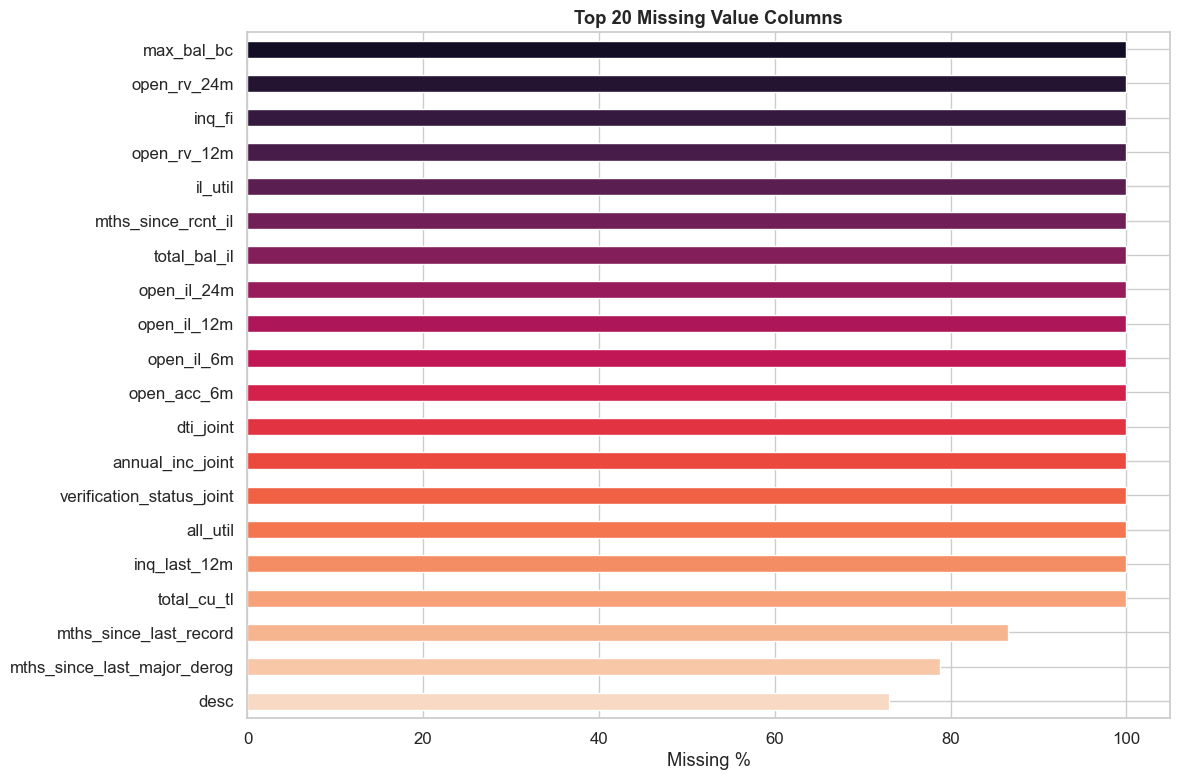

In [5]:
null_pct = (df_raw.isnull().sum()/len(df_raw)*100).sort_values(ascending=False)
null_pct = null_pct[null_pct>0]
print(f"Columns with nulls: {len(null_pct)}/{df_raw.shape[1]}\n")
print(null_pct.head(25).to_string())

fig, ax = plt.subplots(figsize=(12,8))
null_pct.head(20).plot(kind="barh", color=sns.color_palette("rocket",20), ax=ax)
ax.set_xlabel("Missing %"); ax.set_title("Top 20 Missing Value Columns", fontweight="bold")
ax.invert_yaxis(); plt.tight_layout(); plt.show()


### 1.4 Target Variable: loan_status


loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


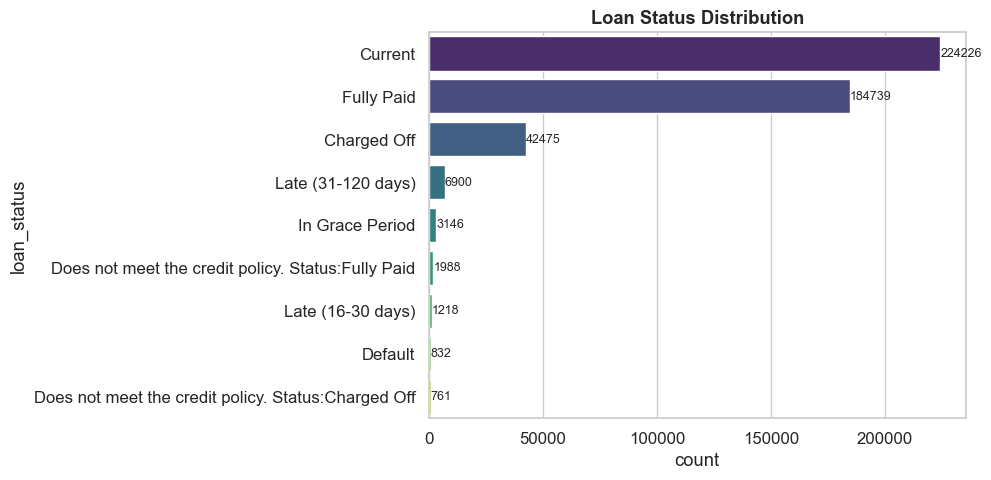

In [6]:
print(df_raw["loan_status"].value_counts())
fig, ax = plt.subplots(figsize=(10,5))
order = df_raw["loan_status"].value_counts().index
sns.countplot(y="loan_status", data=df_raw, order=order, palette="viridis", ax=ax)
ax.set_title("Loan Status Distribution", fontweight="bold")
for c in ax.containers: ax.bar_label(c, fmt="%d", fontsize=9)
plt.tight_layout(); plt.show()


### 1.5 Target Definition
Untuk mendapatkan label yang **bersih**, kita hanya gunakan loan yang sudah selesai:
- **Good Debt (0):** `Fully Paid`
- **Bad Debt (1):** `Charged Off`, `Default`

Loan dengan status `Current`, `Late`, `In Grace Period` **dibuang** karena outcome-nya belum diketahui.


Rows after filtering: 228,046 (dropped 238,239 ambiguous loans)

Target distribution:
target
0    184739
1     43307
Name: count, dtype: int64

Bad debt rate: 0.1899 (19.0%)


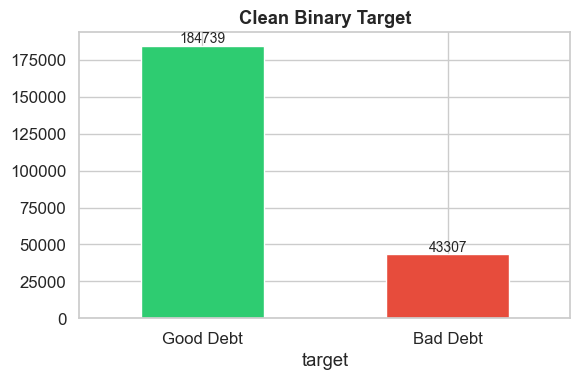

In [7]:
GOOD = {"Fully Paid"}
BAD = {"Charged Off", "Default"}

df = df_raw[df_raw["loan_status"].isin(GOOD | BAD)].copy()
df["target"] = np.where(df["loan_status"].isin(GOOD), 0, 1)

print(f"Rows after filtering: {len(df):,} (dropped {len(df_raw)-len(df):,} ambiguous loans)")
print(f"\nTarget distribution:\n{df['target'].value_counts()}")
print(f"\nBad debt rate: {df['target'].mean():.4f} ({df['target'].mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6,4))
df["target"].value_counts().plot(kind="bar", color=["#2ecc71","#e74c3c"], ax=ax)
ax.set_xticklabels(["Good Debt","Bad Debt"], rotation=0)
ax.set_title("Clean Binary Target", fontweight="bold")
for c in ax.containers: ax.bar_label(c, fmt="%d", fontsize=10)
plt.tight_layout(); plt.show()


---
# 2. Exploratory Data Analysis


### 2.1 Univariate - Numeric


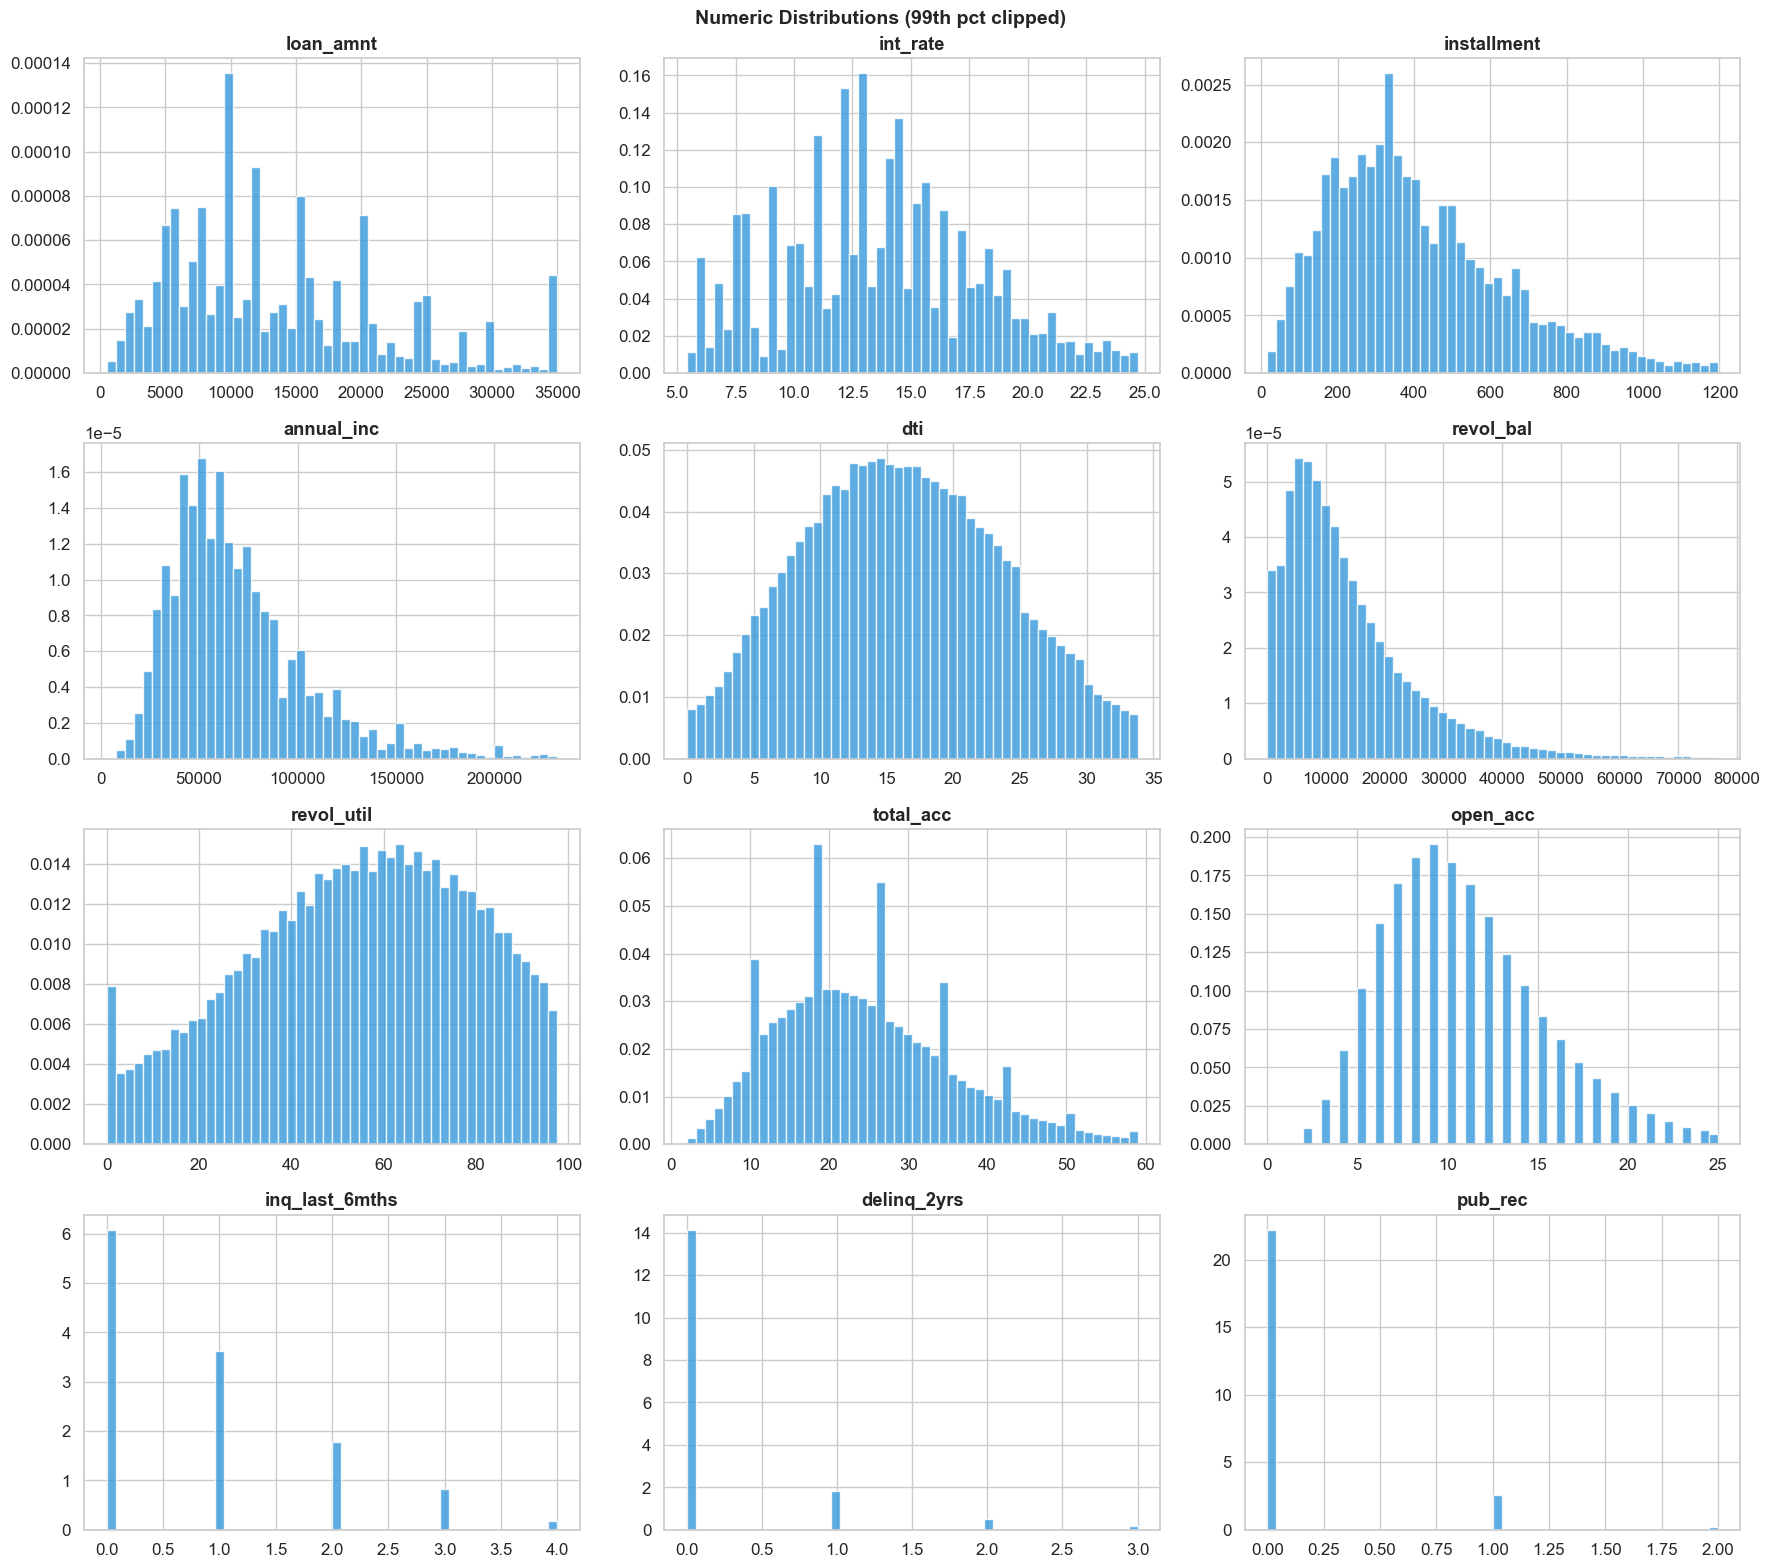

In [8]:
num_cols = ["loan_amnt","int_rate","installment","annual_inc","dti","revol_bal",
            "revol_util","total_acc","open_acc","inq_last_6mths","delinq_2yrs","pub_rec"]
fig, axes = plt.subplots(4,3,figsize=(18,16))
for i, col in enumerate(num_cols):
    ax = axes[i//3, i%3]
    data = pd.to_numeric(df[col], errors="coerce").dropna()
    q99 = data.quantile(0.99)
    ax.hist(data[data<=q99], bins=50, color="#3498db", edgecolor="white", alpha=0.8, density=True)
    ax.set_title(col, fontweight="bold")
plt.suptitle("Numeric Distributions (99th pct clipped)", fontweight="bold", fontsize=14)
plt.tight_layout(); plt.show()


### 2.2 Univariate - Categorical


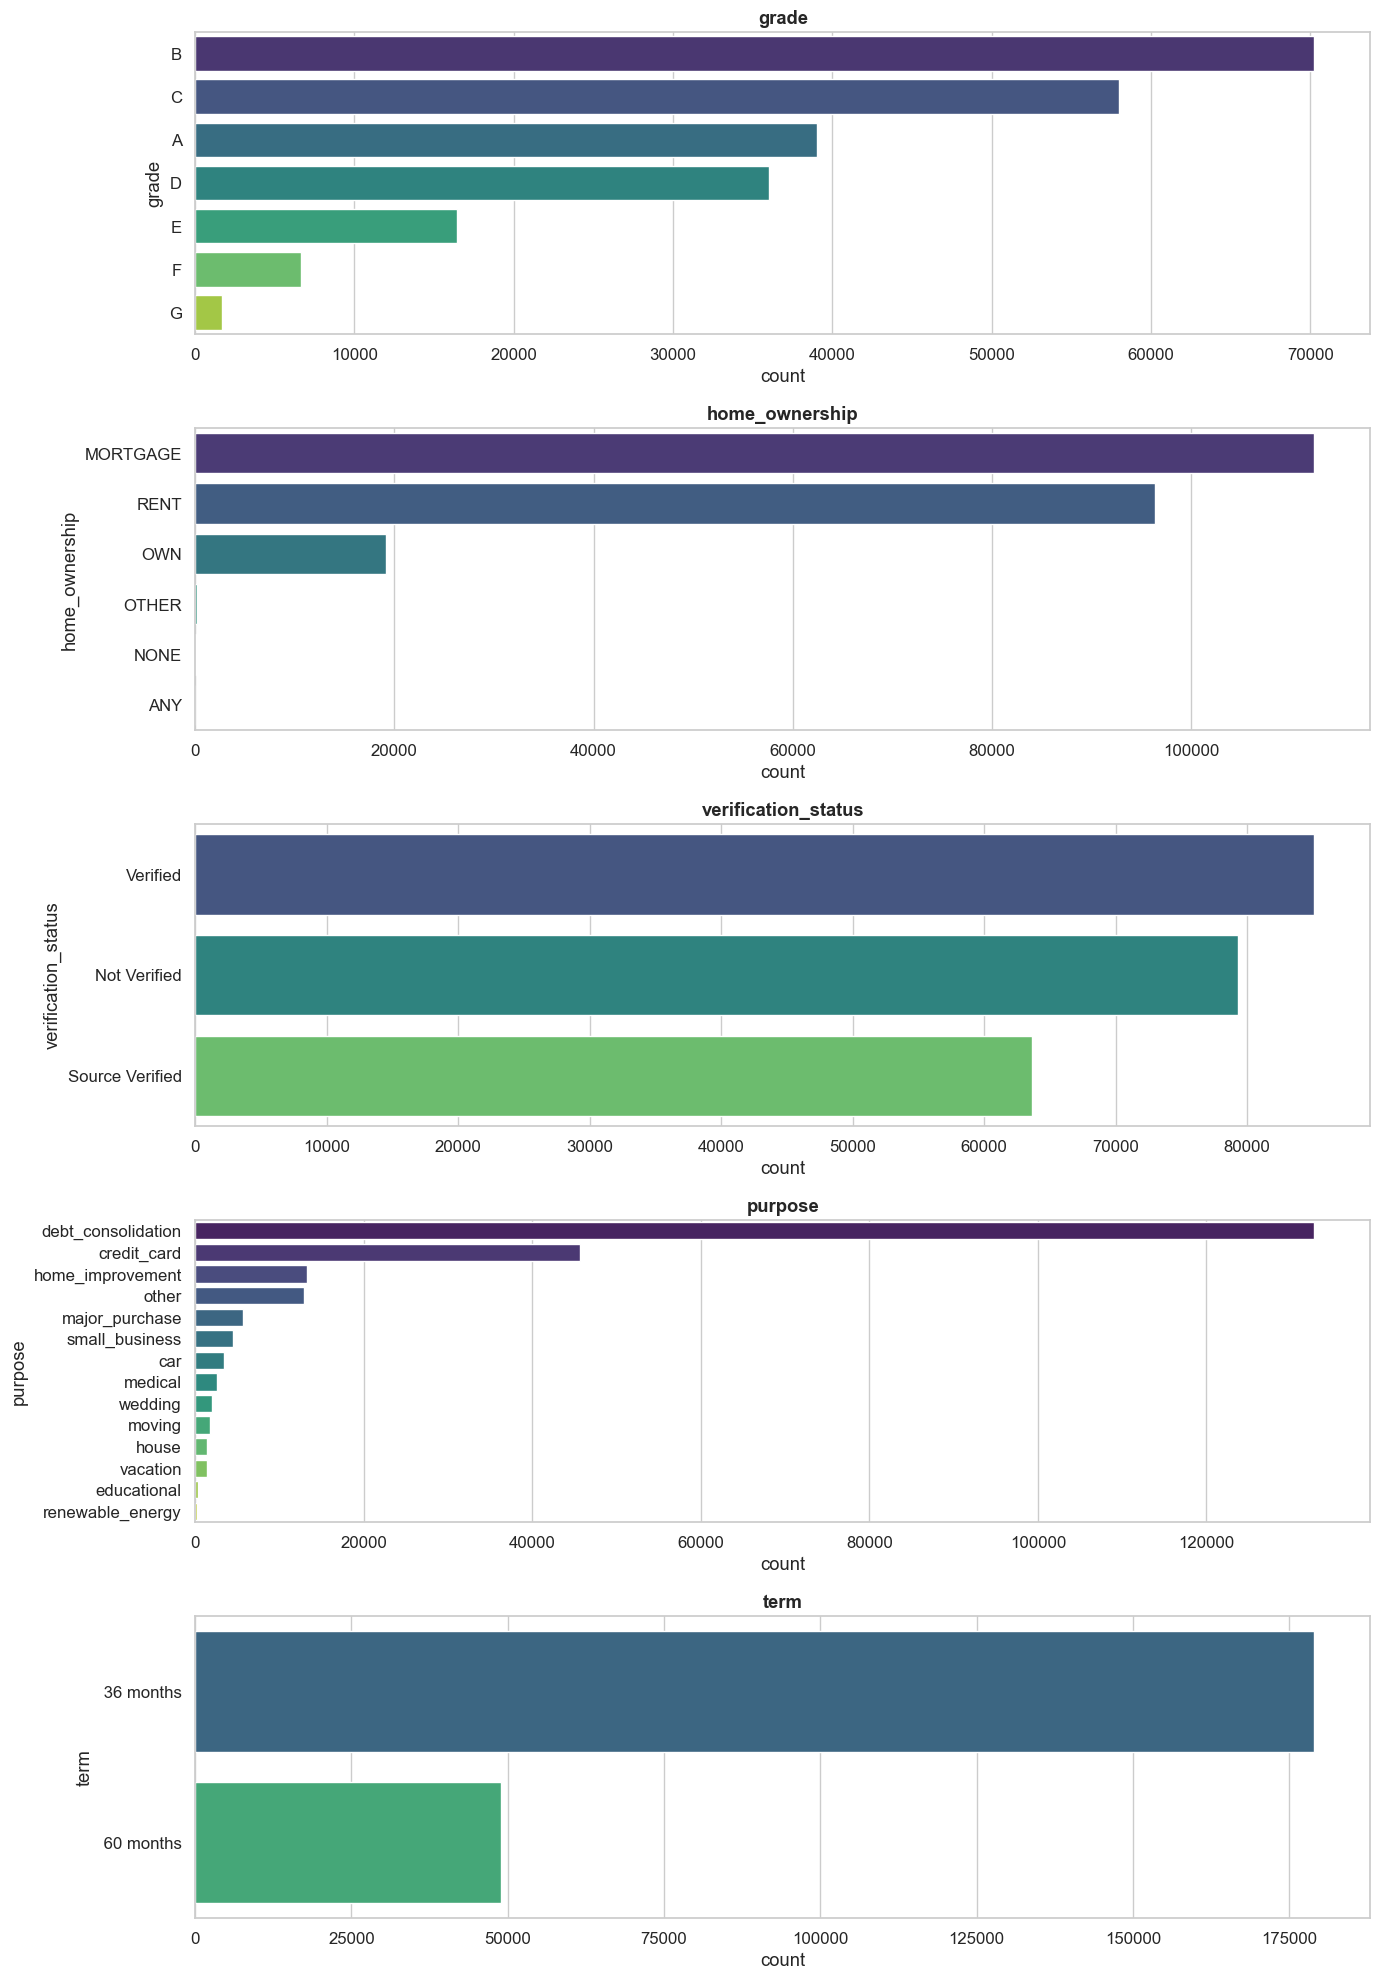

In [9]:
cat_cols = ["grade","home_ownership","verification_status","purpose","term"]
fig, axes = plt.subplots(len(cat_cols),1,figsize=(14,4*len(cat_cols)))
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index[:15]
    sns.countplot(y=col, data=df, order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(f"{col}", fontweight="bold")
plt.tight_layout(); plt.show()


### 2.3 Bivariate - Numeric vs Target


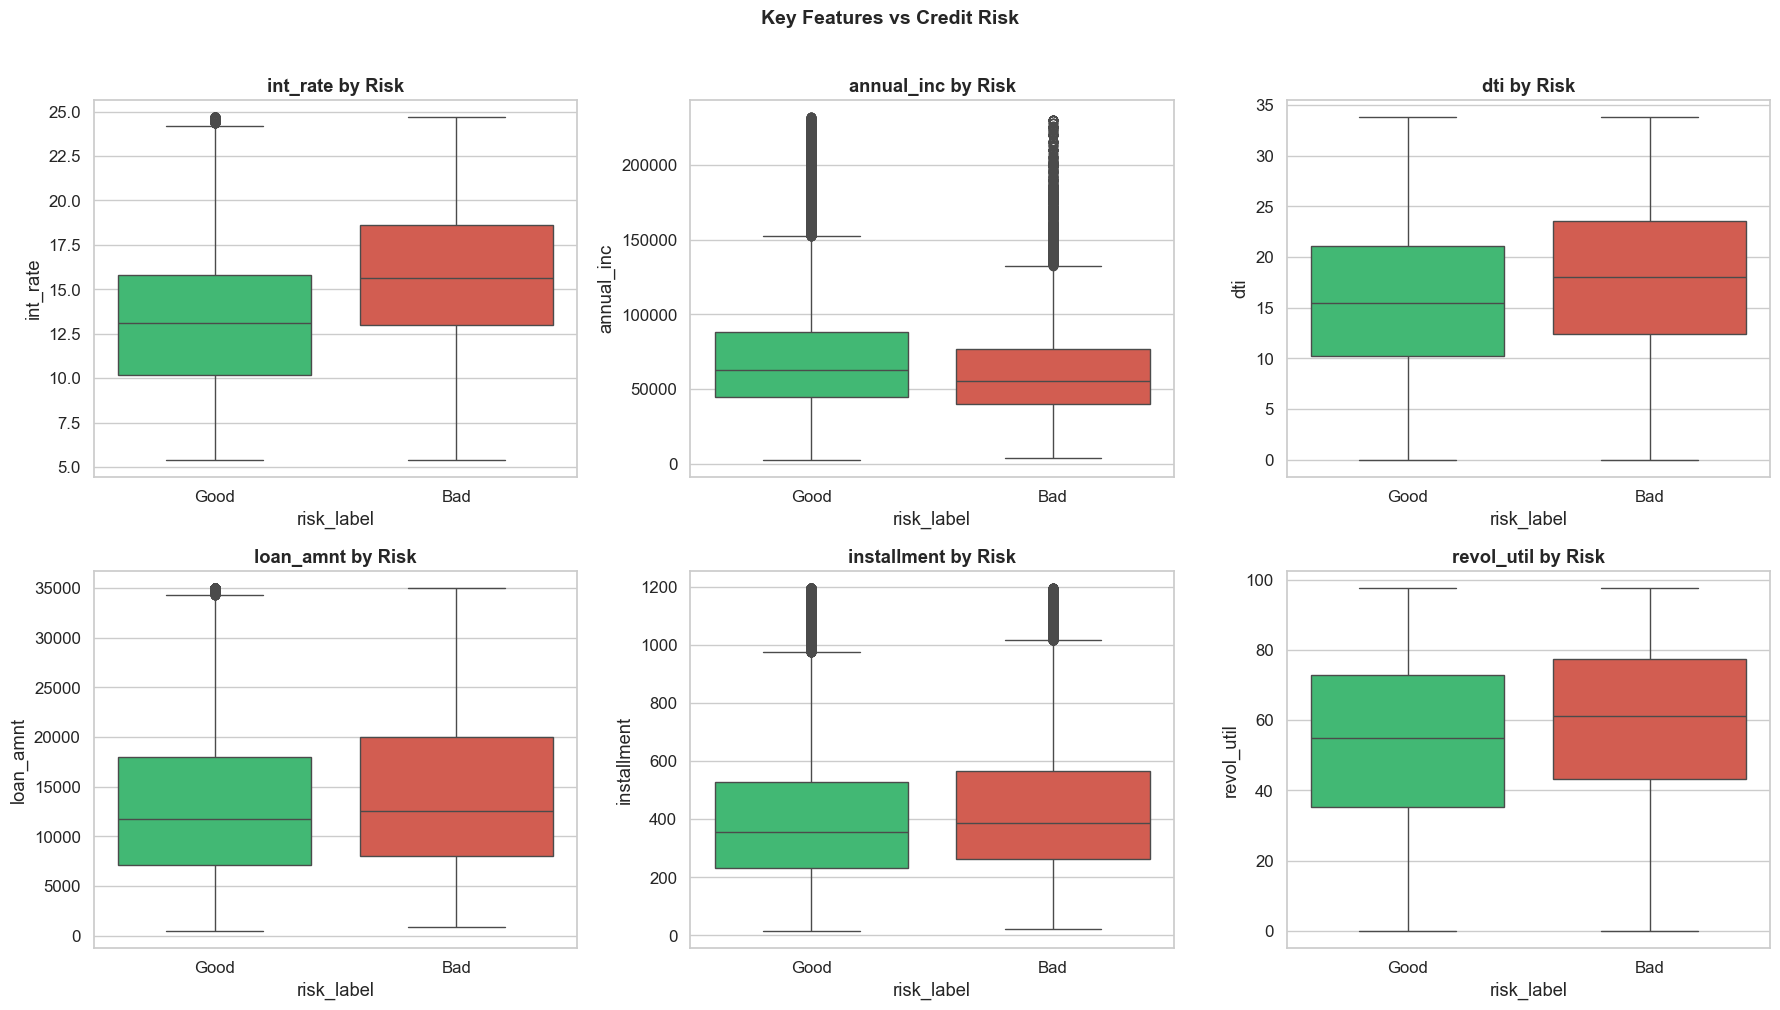

In [10]:
df["risk_label"] = df["target"].map({0:"Good",1:"Bad"})
biv = ["int_rate","annual_inc","dti","loan_amnt","installment","revol_util"]
fig, axes = plt.subplots(2,3,figsize=(18,10))
for i, col in enumerate(biv):
    ax = axes[i//3, i%3]
    d = df[[col,"risk_label"]].copy()
    d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna(); d = d[d[col]<=d[col].quantile(0.99)]
    sns.boxplot(x="risk_label", y=col, data=d, ax=ax, palette={"Good":"#2ecc71","Bad":"#e74c3c"})
    ax.set_title(f"{col} by Risk", fontweight="bold")
plt.suptitle("Key Features vs Credit Risk", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### 2.4 Default Rate by Category


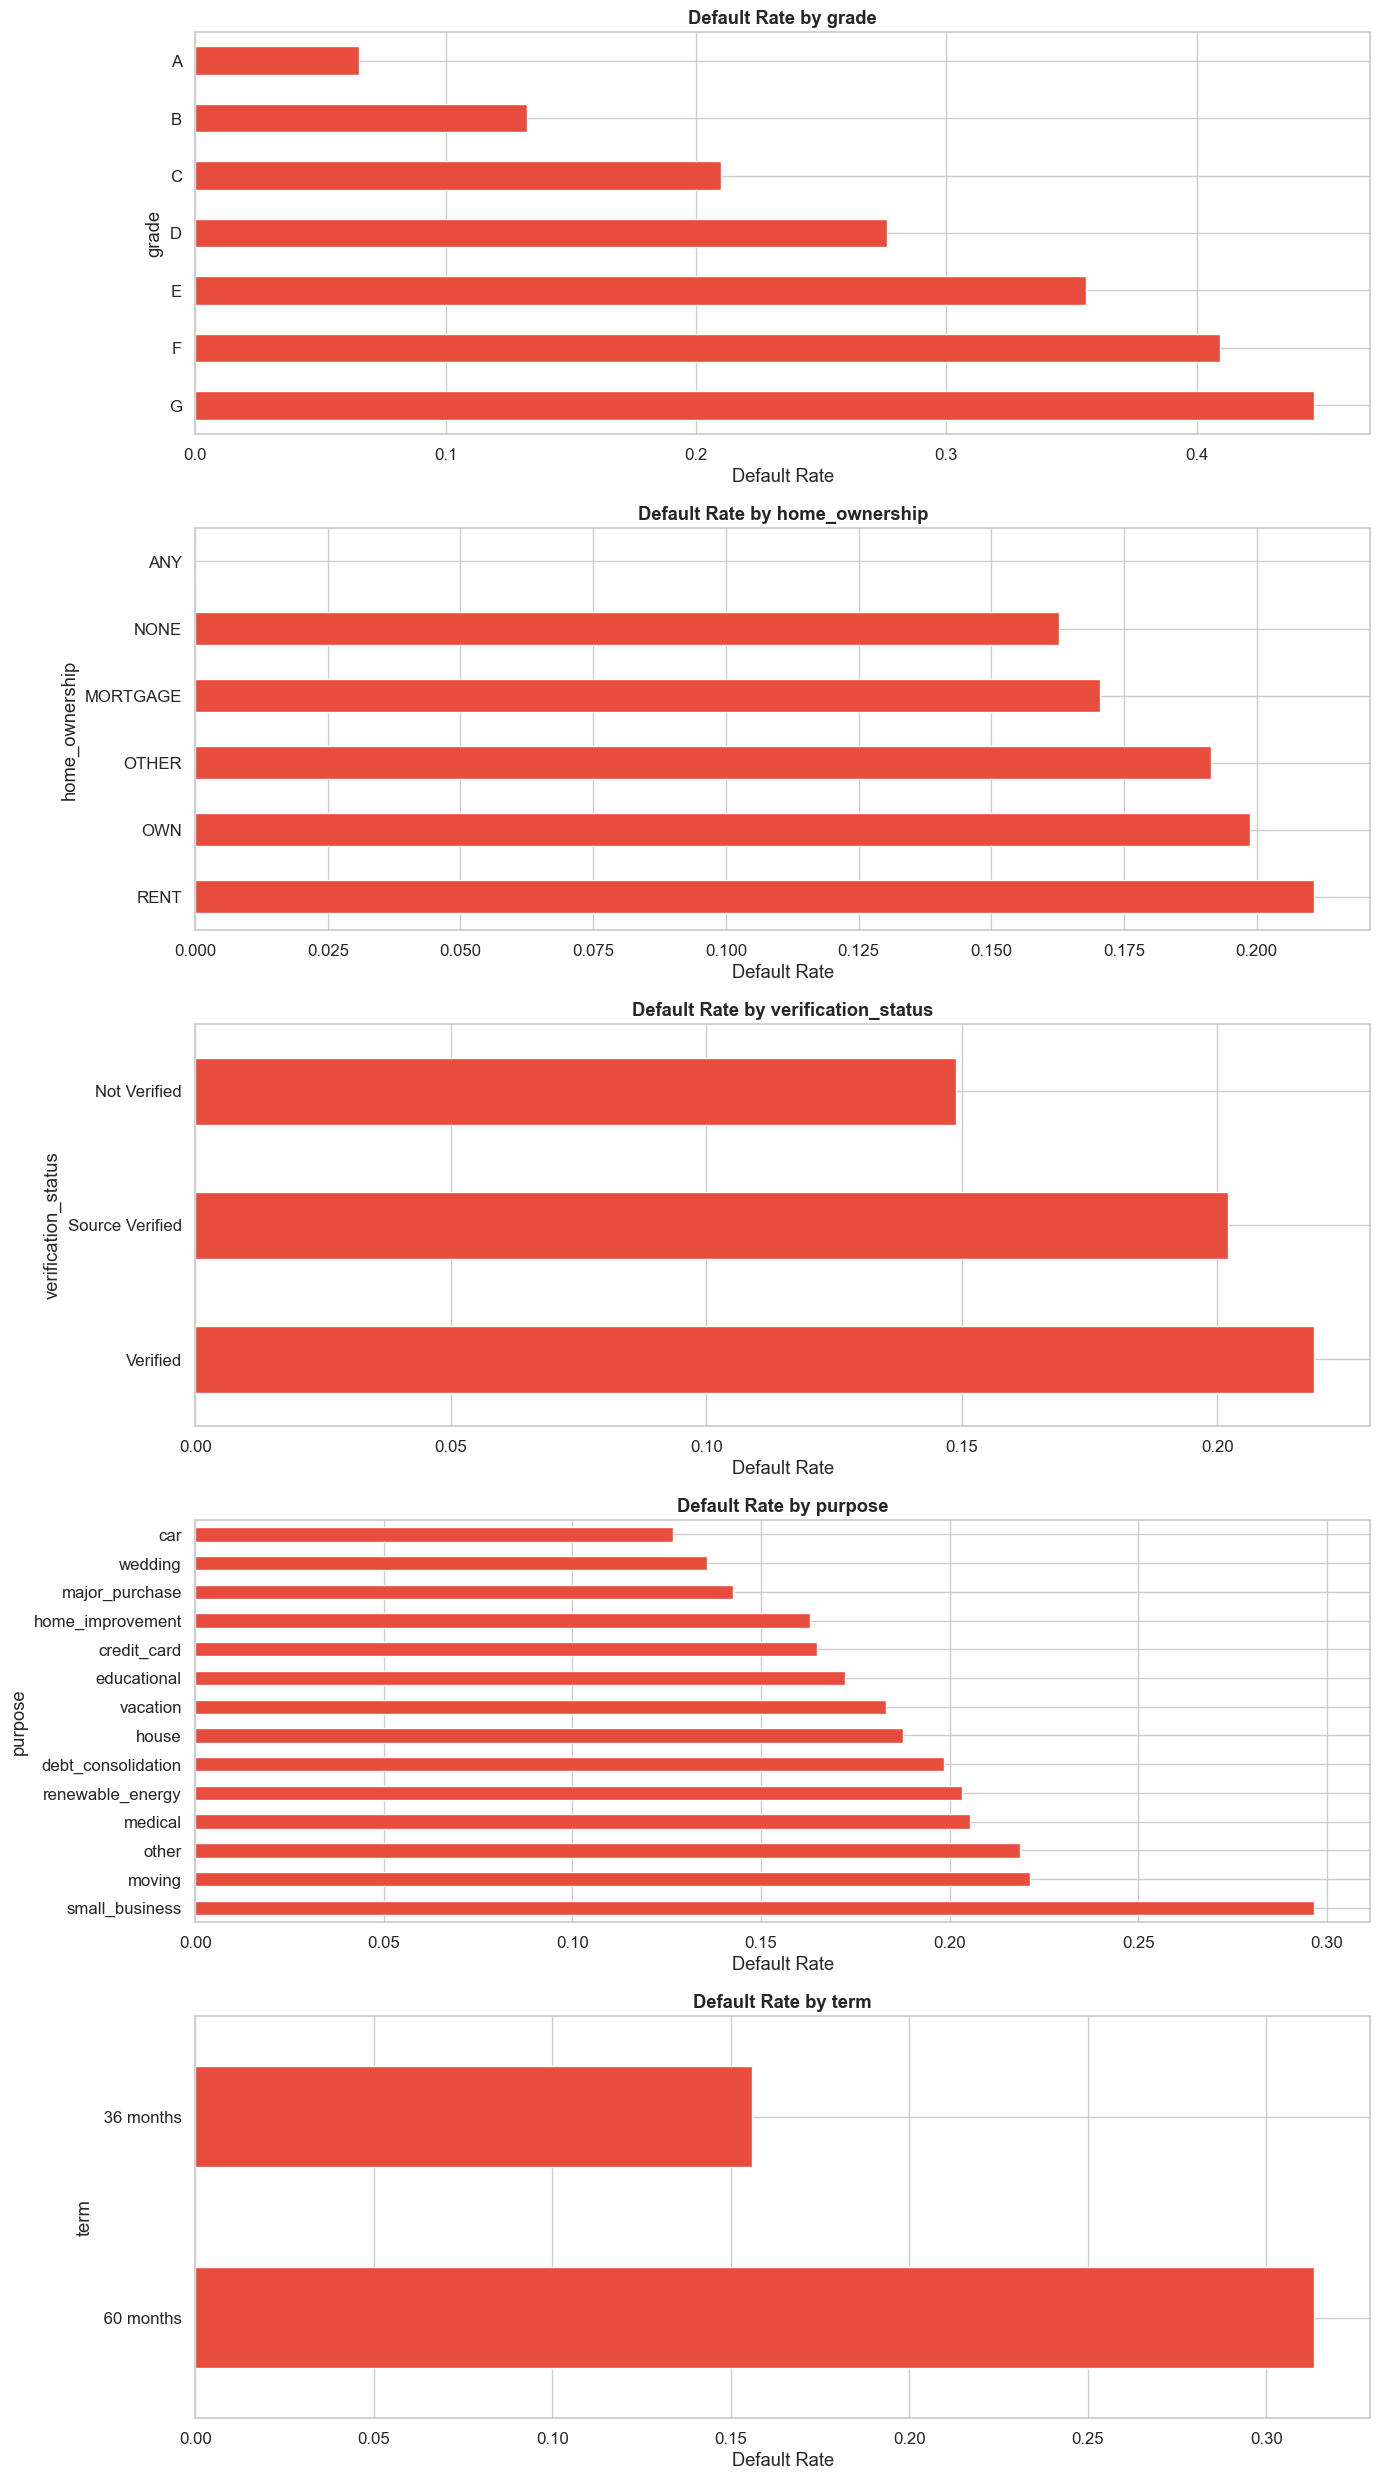

In [11]:
fig, axes = plt.subplots(5,1,figsize=(14,25))
for i, col in enumerate(["grade","home_ownership","verification_status","purpose","term"]):
    rates = df.groupby(col)["target"].mean().sort_values(ascending=False).head(15)
    rates.plot(kind="barh", ax=axes[i], color="#e74c3c", edgecolor="white")
    axes[i].set_title(f"Default Rate by {col}", fontweight="bold")
    axes[i].set_xlabel("Default Rate")
plt.tight_layout(); plt.show()


### 2.5 Correlation Heatmap


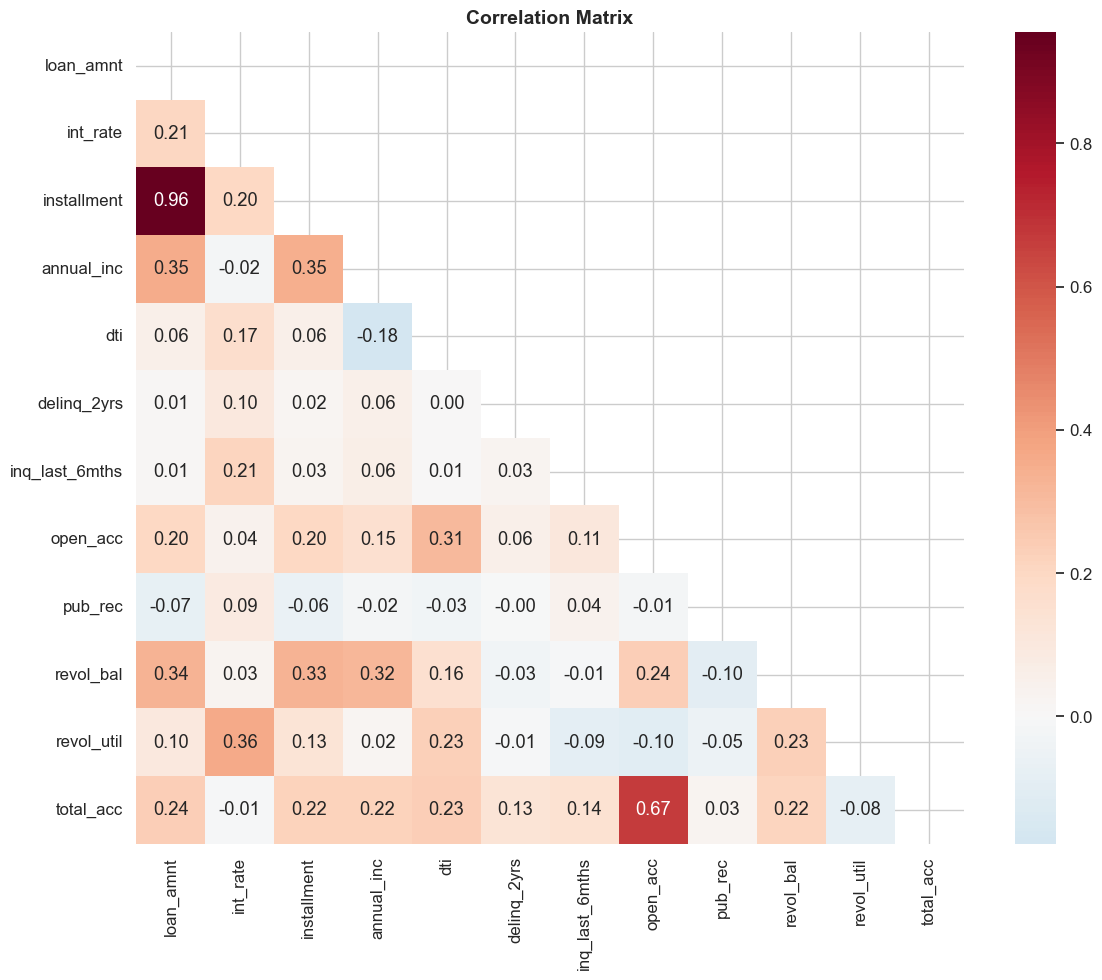

In [12]:
corr_cols = ["loan_amnt","int_rate","installment","annual_inc","dti","delinq_2yrs",
             "inq_last_6mths","open_acc","pub_rec","revol_bal","revol_util","total_acc"]
corr_df = df[corr_cols].apply(pd.to_numeric, errors="coerce")
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation Matrix", fontweight="bold", fontsize=14)
plt.tight_layout(); plt.show()


### 2.6 Business Insights & Strategic Recommendations (from EDA)

Berdasarkan hasil Exploratory Data Analysis (EDA) di atas, berikut adalah temuan bisnis strategis (*Business Insights*) beserta rekomendasinya untuk tim manajemen:

**1. Fenomena *Adverse Selection* pada Suku Bunga (Interest Rate)**
*   **Insight:** Terdapat korelasi positif yang sangat kuat antara tingkat suku bunga (`int_rate`) dengan kegagalan bayar. Nasabah yang dibebankan bunga tinggi justru paling banyak berujung pada *Charged Off / Default*.
*   **Rekomendasi Bisnis:** Praktik sekadar "menaikkan suku bunga untuk mengkompensasi profil risiko tinggi" terbukti kurang efektif dan justru memicu gagal bayar. Disarankan untuk menggunakan model prediktif (Machine Learning) ini di fase **Prescreening awal**. Jika probabilitas default sangat tinggi, tolak aplikasi tersebut secara penuh alih-alih meloloskannya dengan bunga mencekik.

**2. Pengetatan Kebijakan (*Tightening Policy*) untuk Grade E, F, G**
*   **Insight:** *Default rate* melonjak drastis melewati angka 30% pada peminjam dengan grade E, F, dan G.
*   **Rekomendasi Bisnis:** Segera terapkan penghentian *Auto-Approval* untuk calon nasabah yang masuk ke dalam Grade E ke bawah. Wajibkan *Manual Review* (verifikasi dokumen fisik) oleh tim *Underwriter* senior, atau turunkan limit maksimal pinjaman (*Credit Ceiling*) secara drastis untuk kelompok ini guna menekan eksposur risiko.

**3. *Debt-Trap* pada Tujuan Pinjaman (*Debt Consolidation*)**
*   **Insight:** Mayoritas absolut peminjam mengajukan pinjaman untuk tujuan *Debt Consolidation* (gali lubang tutup lubang).
*   **Rekomendasi Bisnis:** Segmen ini terbukti memiliki risiko kerentanan kas yang tinggi. Tim produk disarankan untuk membuat program pinjaman *Restrukturisasi/Advisory* khusus yang pencairannya langsung ditransfer ke kreditur asal (tidak ditransfer *cash* ke rekening nasabah) untuk mencegah penyalahgunaan dana pinjaman baru.

**4. Kerentanan Likuiditas berdasarkan Status Hunian**
*   **Insight:** Nasabah berstatus penyewa (`RENT`) menunjukkan tingkat *default* yang secara konsisten lebih tinggi dibandingkan nasabah yang memiliki rumah/KPR (`OWN` / `MORTGAGE`).
*   **Rekomendasi Bisnis:** Untuk nasabah dengan status `RENT`, turunkan *threshold* toleransi *Debt-to-Income* (DTI) ratio. Jika batas DTI normal adalah 35%, maka untuk penyewa, batas aman maksimal yang disetujui sebaiknya di kisaran 25-30% karena adanya beban tetap (biaya sewa) yang tidak tercatat di biro kredit konvensional.


---
# 3. Data Preparation


### 3.1 Clean & Drop


In [13]:
# Clean special columns
if df["int_rate"].dtype == object:
    df["int_rate"] = df["int_rate"].astype(str).str.replace("%","",regex=False).apply(pd.to_numeric, errors="coerce")
if df["revol_util"].dtype == object:
    df["revol_util"] = df["revol_util"].astype(str).str.replace("%","",regex=False).apply(pd.to_numeric, errors="coerce")
df["term"] = df["term"].astype(str).str.extract(r"(\d+)")[0].apply(pd.to_numeric, errors="coerce")
emp_map = {"< 1 year":0,"1 year":1,"2 years":2,"3 years":3,"4 years":4,"5 years":5,
           "6 years":6,"7 years":7,"8 years":8,"9 years":9,"10+ years":10}
df["emp_length"] = df["emp_length"].map(emp_map)

# Drop leakage
LEAK = ["Unnamed: 0","id","member_id","url","desc","title","emp_title","zip_code",
        "funded_amnt","funded_amnt_inv","out_prncp","out_prncp_inv","total_pymnt",
        "total_pymnt_inv","total_rec_prncp","total_rec_int","total_rec_late_fee",
        "recoveries","collection_recovery_fee","last_pymnt_d","last_pymnt_amnt",
        "next_pymnt_d","last_credit_pull_d","policy_code","pymnt_plan",
        "annual_inc_joint","dti_joint","verification_status_joint",
        "mths_since_last_delinq","mths_since_last_record","mths_since_last_major_derog",
        "open_acc_6m","open_il_6m","open_il_12m","open_il_24m","mths_since_rcnt_il",
        "total_bal_il","il_util","open_rv_12m","open_rv_24m","max_bal_bc","all_util",
        "inq_fi","total_cu_tl","inq_last_12m",
        "loan_status","risk_label"]
existing = [c for c in LEAK if c in df.columns]
df.drop(columns=existing, inplace=True)
print(f"Dropped {len(existing)} cols. Remaining: {df.shape[1]}")


Dropped 47 cols. Remaining: 30


### 3.2 Feature Engineering


In [14]:
# Date -> credit history length
issue = pd.to_datetime(df["issue_d"], format="mixed", errors="coerce")
ecl = pd.to_datetime(df["earliest_cr_line"], format="mixed", errors="coerce")
df["credit_history_months"] = (issue.dt.year-ecl.dt.year)*12 + (issue.dt.month-ecl.dt.month)
df.drop(columns=["issue_d","earliest_cr_line"], inplace=True)

# Ratio features
df["installment_to_income"] = df["installment"] / (df["annual_inc"]/12 + 1)
df["loan_to_income"] = df["loan_amnt"] / (df["annual_inc"] + 1)
df["revol_to_income"] = df["revol_bal"] / (df["annual_inc"] + 1)
df["open_acc_ratio"] = df["open_acc"] / (df["total_acc"] + 1)

# New: leverage & utilization ratios from data dictionary insights
df["revol_utilization"] = df["revol_bal"] / (df["total_rev_hi_lim"] + 1)
df["total_debt_ratio"] = df["tot_cur_bal"] / (df["annual_inc"] + 1)
df["collection_flag"] = (df["tot_coll_amt"] > 0).astype(int)

print(f"Shape after feature engineering: {df.shape}")
print(f"Engineered features: installment_to_income, loan_to_income, revol_to_income,")
print(f"  open_acc_ratio, revol_utilization, total_debt_ratio, collection_flag, credit_history_months")


Shape after feature engineering: (228046, 36)
Engineered features: installment_to_income, loan_to_income, revol_to_income,
  open_acc_ratio, revol_utilization, total_debt_ratio, collection_flag, credit_history_months


### 3.3 Imputation + Outlier Capping


In [15]:
# Impute
null_before = df.isnull().sum().sum()
for col in df.columns:
    if df[col].isnull().sum() == 0: continue
    if df[col].dtype in ("float64","int64"):
        df[col].fillna(df[col].median(), inplace=True)
    else:
        m = df[col].mode()
        if len(m)>0: df[col].fillna(m[0], inplace=True)
print(f"Nulls: {null_before:,} -> {df.isnull().sum().sum():,}")

# Cap outliers
for col in df.select_dtypes(include=[np.number]).columns:
    if col == "target": continue
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    df[col] = df[col].clip(q1-1.5*iqr, q3+1.5*iqr)
print("Outliers capped.")


Nulls: 345,999 -> 345,999


Outliers capped.


### 3.4 Encoding


In [16]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical: {cat_cols}")
for col in cat_cols:
    if df[col].nunique() > 10:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    else:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
        df = pd.concat([df.drop(columns=[col]), dummies], axis=1)
df.fillna(0, inplace=True)
df.replace([np.inf, -np.inf], 0, inplace=True)
print(f"Shape: {df.shape}")


Categorical: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']


Shape: (228046, 45)


### 3.5 Train/Test Split + Scaling


In [17]:
X = df.drop(columns=["target"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# Scale (no SMOTE - use class_weight in model instead to avoid overfitting)
scaler = StandardScaler()
feature_names = X_train.columns
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

print(f"X_train: {X_train_sc.shape}")
print(f"X_test:  {X_test_sc.shape}")
print(f"\ny_train default rate: {y_train.mean():.4f}")
print(f"y_test  default rate: {y_test.mean():.4f}")


X_train: (182436, 44)
X_test:  (45610, 44)

y_train default rate: 0.1899
y_test  default rate: 0.1899


---
# 4. Data Modelling
> **Business context:** False Negative (menyetujui bad debt) lebih berbahaya daripada False Positive.  
> Optimize ke **F1-score** yang menyeimbangkan Precision & Recall.


### 4.1 Logistic Regression


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=SEED, max_iter=1000, solver="saga",
                       class_weight="balanced", n_jobs=-1),
    {"C": [0.001,0.01,0.05,0.1,0.5,1.0], "penalty":["l1","l2"]},
    n_iter=10, cv=cv, scoring="f1", random_state=SEED, n_jobs=-1, refit=True
)
lr_search.fit(X_train_sc, y_train)
lr_best = lr_search.best_estimator_
print(f"Best params: {lr_search.best_params_}")
print(f"Best CV F1: {lr_search.best_score_:.4f}")


Best params: {'penalty': 'l1', 'C': 0.05}
Best CV F1: 0.4136


### 4.2 XGBoost


In [19]:
# scale_pos_weight = ratio neg/pos for class balancing
spw = int((y_train==0).sum() / (y_train==1).sum())
print(f"scale_pos_weight = {spw}")

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=SEED, eval_metric="logloss", n_jobs=-1,
                  tree_method="hist", scale_pos_weight=spw,
                  reg_alpha=1.0, reg_lambda=5.0),
    {"n_estimators":[100,200,300], "max_depth":[3,4,5],
     "learning_rate":[0.01,0.05,0.1], "subsample":[0.7,0.8],
     "colsample_bytree":[0.7,0.8], "min_child_weight":[3,5,7],
     "gamma":[0.1,0.3,0.5]},
    n_iter=30, cv=cv, scoring="f1", random_state=SEED, n_jobs=-1, refit=True
)
xgb_search.fit(X_train_sc, y_train)
xgb_best = xgb_search.best_estimator_
print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV F1: {xgb_search.best_score_:.4f}")


scale_pos_weight = 4


Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}
Best CV F1: 0.4228


### 4.3 Stacking Ensemble


In [20]:
# Stacking: LR + XGB + RF as base learners, LR as meta-learner
stack = StackingClassifier(
    estimators=[
        ("lr", lr_best),
        ("xgb", xgb_best),
        ("rf", RandomForestClassifier(n_estimators=200, max_depth=5, class_weight="balanced",
                                      random_state=SEED, n_jobs=-1))
    ],
    final_estimator=LogisticRegression(random_state=SEED, max_iter=1000, class_weight="balanced"),
    cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    stack_method="predict_proba",
    n_jobs=-1
)
stack.fit(X_train_sc, y_train)
print("Stacking Ensemble trained.")
stack_cv = cross_val_score(stack, X_train_sc, y_train, cv=cv, scoring="f1", n_jobs=-1)
print(f"Stacking CV F1: {stack_cv.mean():.4f} +/- {stack_cv.std():.4f}")


Stacking Ensemble trained.


Stacking CV F1: 0.4208 +/- 0.0035


### 4.4 Baseline Evaluation (Before Tuning)
Confusion matrix ketiga model dengan **default threshold 0.5** sebelum threshold tuning.


  BASELINE (threshold=0.5, sebelum threshold tuning)

LR Baseline: TN=23,719 FP=13,229 FN=2,973 TP=5,689 | F1=0.4125

XGB Baseline: TN=25,225 FP=11,723 FN=3,236 TP=5,426 | F1=0.4204



Stack Baseline: TN=23,864 FP=13,084 FN=2,899 TP=5,763 | F1=0.4190


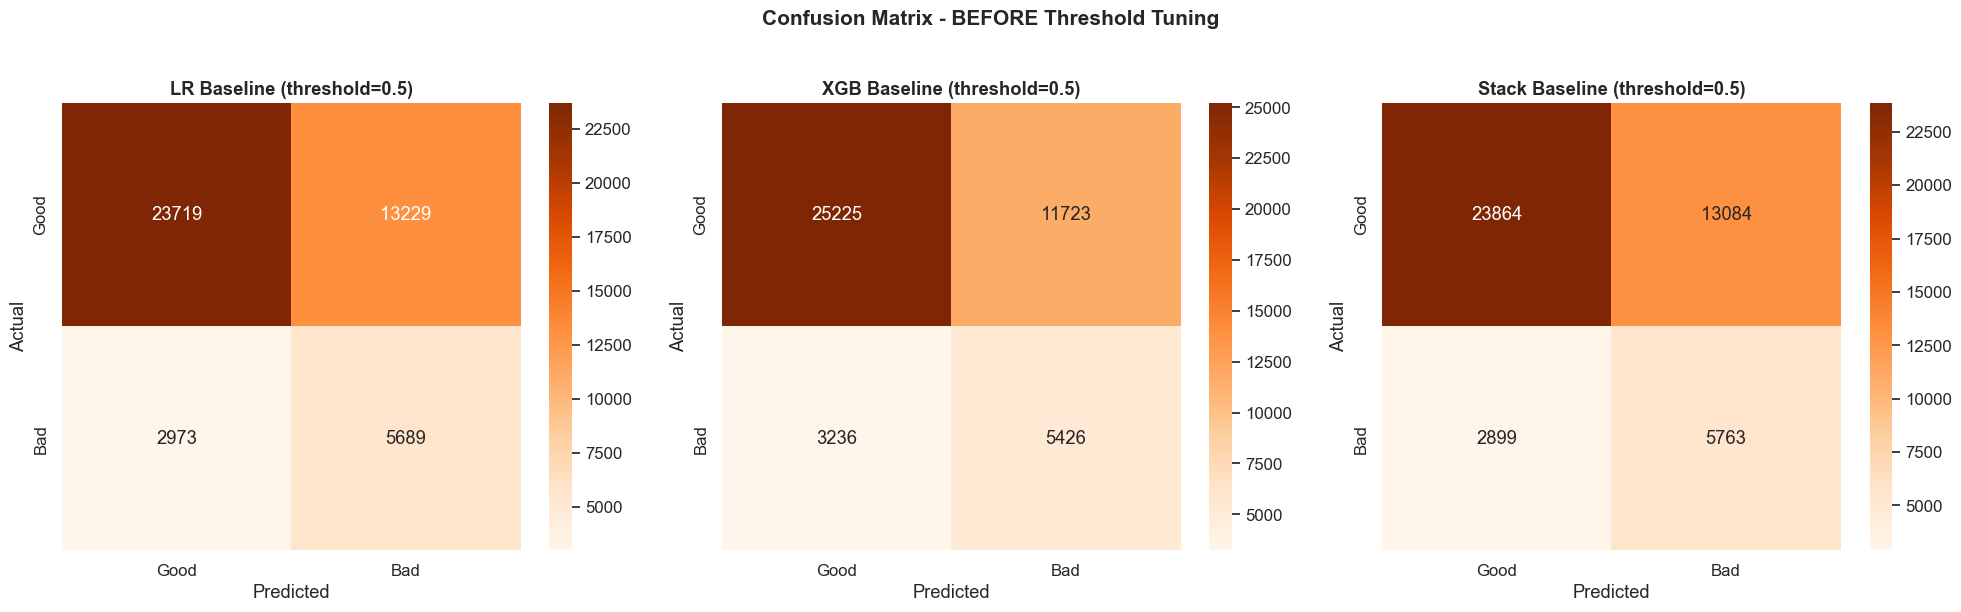

In [21]:
# Baseline: default threshold = 0.5
print("=" * 55)
print("  BASELINE (threshold=0.5, sebelum threshold tuning)")
print("=" * 55)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, model) in zip(axes, [("LR Baseline", lr_best), ("XGB Baseline", xgb_best), ("Stack Baseline", stack)]):
    y_base = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_base)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax,
                xticklabels=["Good","Bad"], yticklabels=["Good","Bad"])
    ax.set_title(f"{name} (threshold=0.5)", fontweight="bold")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
    tn, fp, fn, tp = cm.ravel()
    f1 = 2*tp / (2*tp + fp + fn + 1e-8)
    print(f"\n{name}: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,} | F1={f1:.4f}")
plt.suptitle("Confusion Matrix - BEFORE Threshold Tuning", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.show()


### 4.5 Threshold Tuning


In [22]:
def find_best_threshold(model, X, y):
    probs = model.predict_proba(X)[:,1]
    p, r, t = precision_recall_curve(y, probs)
    f1s = 2*(p*r)/(p+r+1e-8)
    idx = np.argmax(f1s)
    return t[idx], f1s[idx]

lr_thresh, _ = find_best_threshold(lr_best, X_test_sc, y_test)
xgb_thresh, _ = find_best_threshold(xgb_best, X_test_sc, y_test)
stack_thresh, _ = find_best_threshold(stack, X_test_sc, y_test)
print(f"LR     optimal threshold: {lr_thresh:.4f}")
print(f"XGB    optimal threshold: {xgb_thresh:.4f}")
print(f"Stack  optimal threshold: {stack_thresh:.4f}")


LR     optimal threshold: 0.5160
XGB    optimal threshold: 0.5135
Stack  optimal threshold: 0.5280


---
# 5. Evaluation


In [23]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, thresh=0.5):
    y_prob = model.predict_proba(X_te)[:,1]
    y_pred = (y_prob >= thresh).astype(int)
    y_tr_prob = model.predict_proba(X_tr)[:,1]
    y_tr_pred = (y_tr_prob >= thresh).astype(int)
    m = {"Accuracy": accuracy_score(y_te, y_pred),
         "Precision": precision_score(y_te, y_pred, zero_division=0),
         "Recall": recall_score(y_te, y_pred, zero_division=0),
         "F1": f1_score(y_te, y_pred, zero_division=0),
         "ROC-AUC": roc_auc_score(y_te, y_prob),
         "Train_F1": f1_score(y_tr, y_tr_pred, zero_division=0)}
    print(f"\n{'='*55}")
    print(f"  {name} (threshold={thresh:.4f})")
    print(f"{'='*55}")
    for k,v in m.items(): print(f"  {k:12s}: {v:.4f}")
    gap = m["Train_F1"] - m["F1"]
    print(f"  Overfit gap : {gap:.4f}", "[!] OVERFITTING" if gap>0.05 else "[OK]")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Good Debt','Bad Debt'])}")
    return m, y_pred, y_prob


### 5.1 Model Evaluation (After Tuning)


In [24]:
lr_m, lr_pred, lr_prob = evaluate("Logistic Regression", lr_best, X_train_sc, y_train, X_test_sc, y_test, lr_thresh)
xgb_m, xgb_pred, xgb_prob = evaluate("XGBoost", xgb_best, X_train_sc, y_train, X_test_sc, y_test, xgb_thresh)
stack_m, stack_pred, stack_prob = evaluate("Stacking Ensemble", stack, X_train_sc, y_train, X_test_sc, y_test, stack_thresh)



  Logistic Regression (threshold=0.5160)
  Accuracy    : 0.6632
  Precision   : 0.3095
  Recall      : 0.6280
  F1          : 0.4146
  ROC-AUC     : 0.7043
  Train_F1    : 0.4155
  Overfit gap : 0.0009 [OK]

              precision    recall  f1-score   support

   Good Debt       0.89      0.67      0.76     36948
    Bad Debt       0.31      0.63      0.41      8662

    accuracy                           0.66     45610
   macro avg       0.60      0.65      0.59     45610
weighted avg       0.78      0.66      0.70     45610




  XGBoost (threshold=0.5135)
  Accuracy    : 0.6859
  Precision   : 0.3245
  Recall      : 0.6046
  F1          : 0.4224
  ROC-AUC     : 0.7138
  Train_F1    : 0.4502
  Overfit gap : 0.0278 [OK]

              precision    recall  f1-score   support

   Good Debt       0.88      0.70      0.78     36948
    Bad Debt       0.32      0.60      0.42      8662

    accuracy                           0.69     45610
   macro avg       0.60      0.65      0.60     45610
weighted avg       0.78      0.69      0.72     45610




  Stacking Ensemble (threshold=0.5280)
  Accuracy    : 0.6766
  Precision   : 0.3195
  Recall      : 0.6221
  F1          : 0.4222
  ROC-AUC     : 0.7138
  Train_F1    : 0.4459
  Overfit gap : 0.0237 [OK]

              precision    recall  f1-score   support

   Good Debt       0.89      0.69      0.78     36948
    Bad Debt       0.32      0.62      0.42      8662

    accuracy                           0.68     45610
   macro avg       0.60      0.66      0.60     45610
weighted avg       0.78      0.68      0.71     45610



### 5.2 Confusion Matrices (After Tuning)
Perbandingan confusion matrix ketiga model **setelah threshold tuning**.


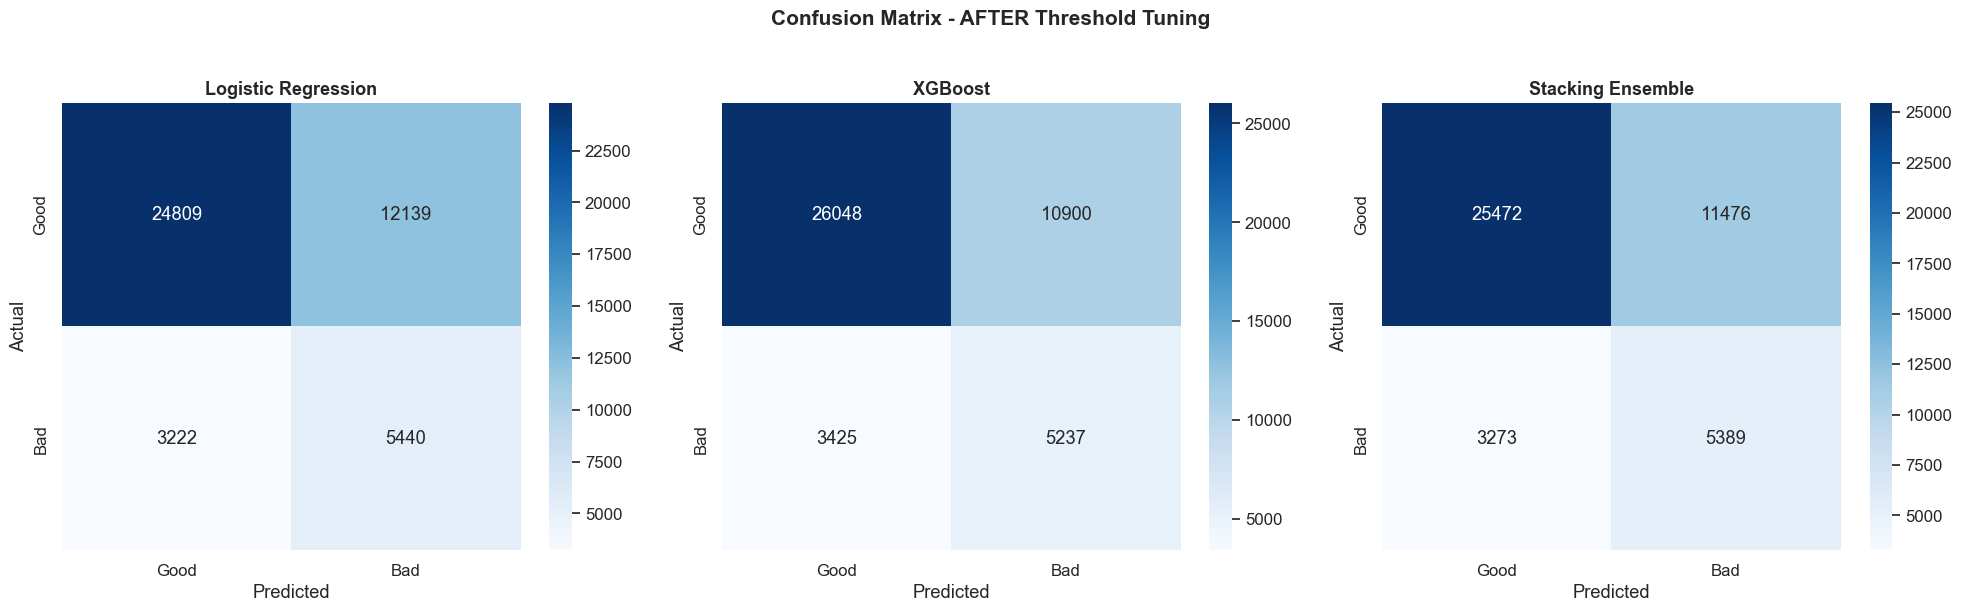


LR: TN=24,809 FP=12,139 FN=3,222 TP=5,440
  FN (approved bad loans): 3,222
  FP (rejected good loans): 12,139

XGB: TN=26,048 FP=10,900 FN=3,425 TP=5,237
  FN (approved bad loans): 3,425
  FP (rejected good loans): 10,900

Stack: TN=25,472 FP=11,476 FN=3,273 TP=5,389
  FN (approved bad loans): 3,273
  FP (rejected good loans): 11,476


In [25]:
fig, axes = plt.subplots(1,3,figsize=(20,6))
for ax,(name,pred) in zip(axes,[("Logistic Regression",lr_pred),("XGBoost",xgb_pred),("Stacking Ensemble",stack_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Good","Bad"], yticklabels=["Good","Bad"])
    ax.set_title(name, fontweight="bold", fontsize=13)
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.suptitle("Confusion Matrix - AFTER Threshold Tuning", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

for name, pred in [("LR",lr_pred),("XGB",xgb_pred),("Stack",stack_pred)]:
    tn,fp,fn,tp = confusion_matrix(y_test, pred).ravel()
    print(f"\n{name}: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
    print(f"  FN (approved bad loans): {fn:,}")
    print(f"  FP (rejected good loans): {fp:,}")


### 5.3 ROC Curve


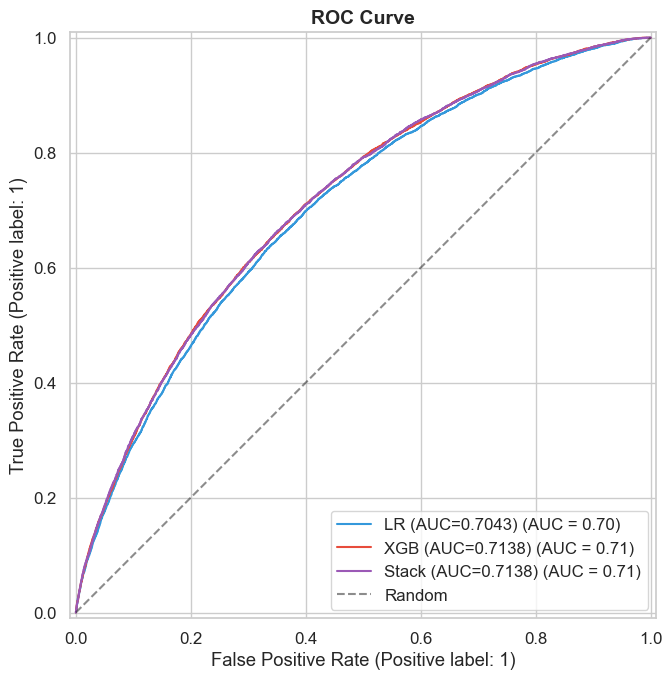

In [26]:
fig, ax = plt.subplots(figsize=(9,7))
RocCurveDisplay.from_estimator(lr_best, X_test_sc, y_test, name=f"LR (AUC={lr_m['ROC-AUC']:.4f})", ax=ax, color="#3498db")
RocCurveDisplay.from_estimator(xgb_best, X_test_sc, y_test, name=f"XGB (AUC={xgb_m['ROC-AUC']:.4f})", ax=ax, color="#e74c3c")
RocCurveDisplay.from_estimator(stack, X_test_sc, y_test, name=f"Stack (AUC={stack_m['ROC-AUC']:.4f})", ax=ax, color="#9b59b6")
ax.plot([0,1],[0,1],"k--",alpha=0.5,label="Random")
ax.set_title("ROC Curve", fontweight="bold", fontsize=14)
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()


### 5.4 Precision-Recall Curve


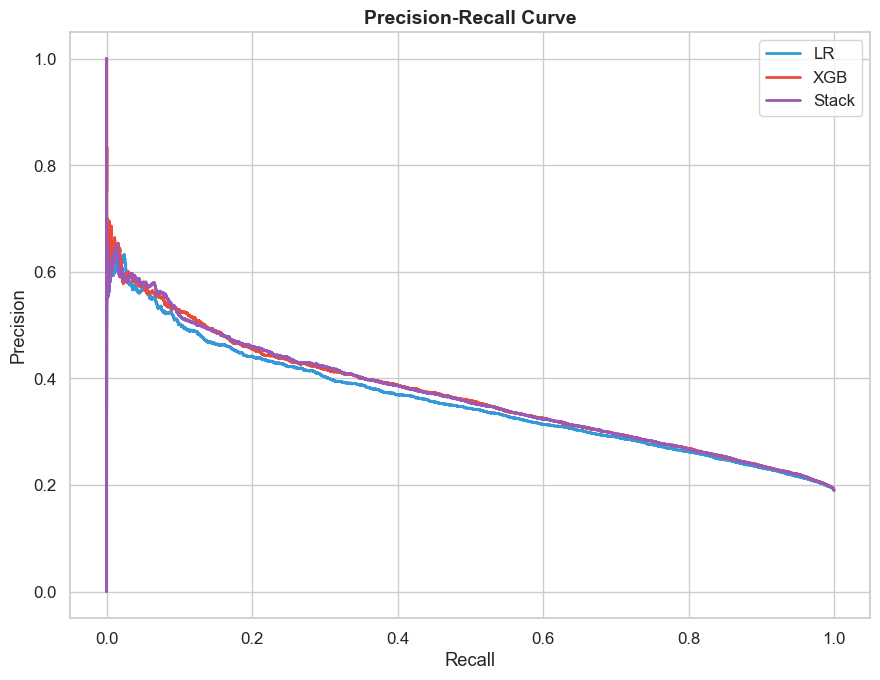

In [27]:
fig, ax = plt.subplots(figsize=(9,7))
for name,prob,color in [("LR",lr_prob,"#3498db"),("XGB",xgb_prob,"#e74c3c"),("Stack",stack_prob,"#9b59b6")]:
    p,r,_ = precision_recall_curve(y_test, prob)
    ax.plot(r, p, label=name, color=color, linewidth=2)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve", fontweight="bold", fontsize=14)
ax.legend(); plt.tight_layout(); plt.show()


### 5.5 Feature Importance


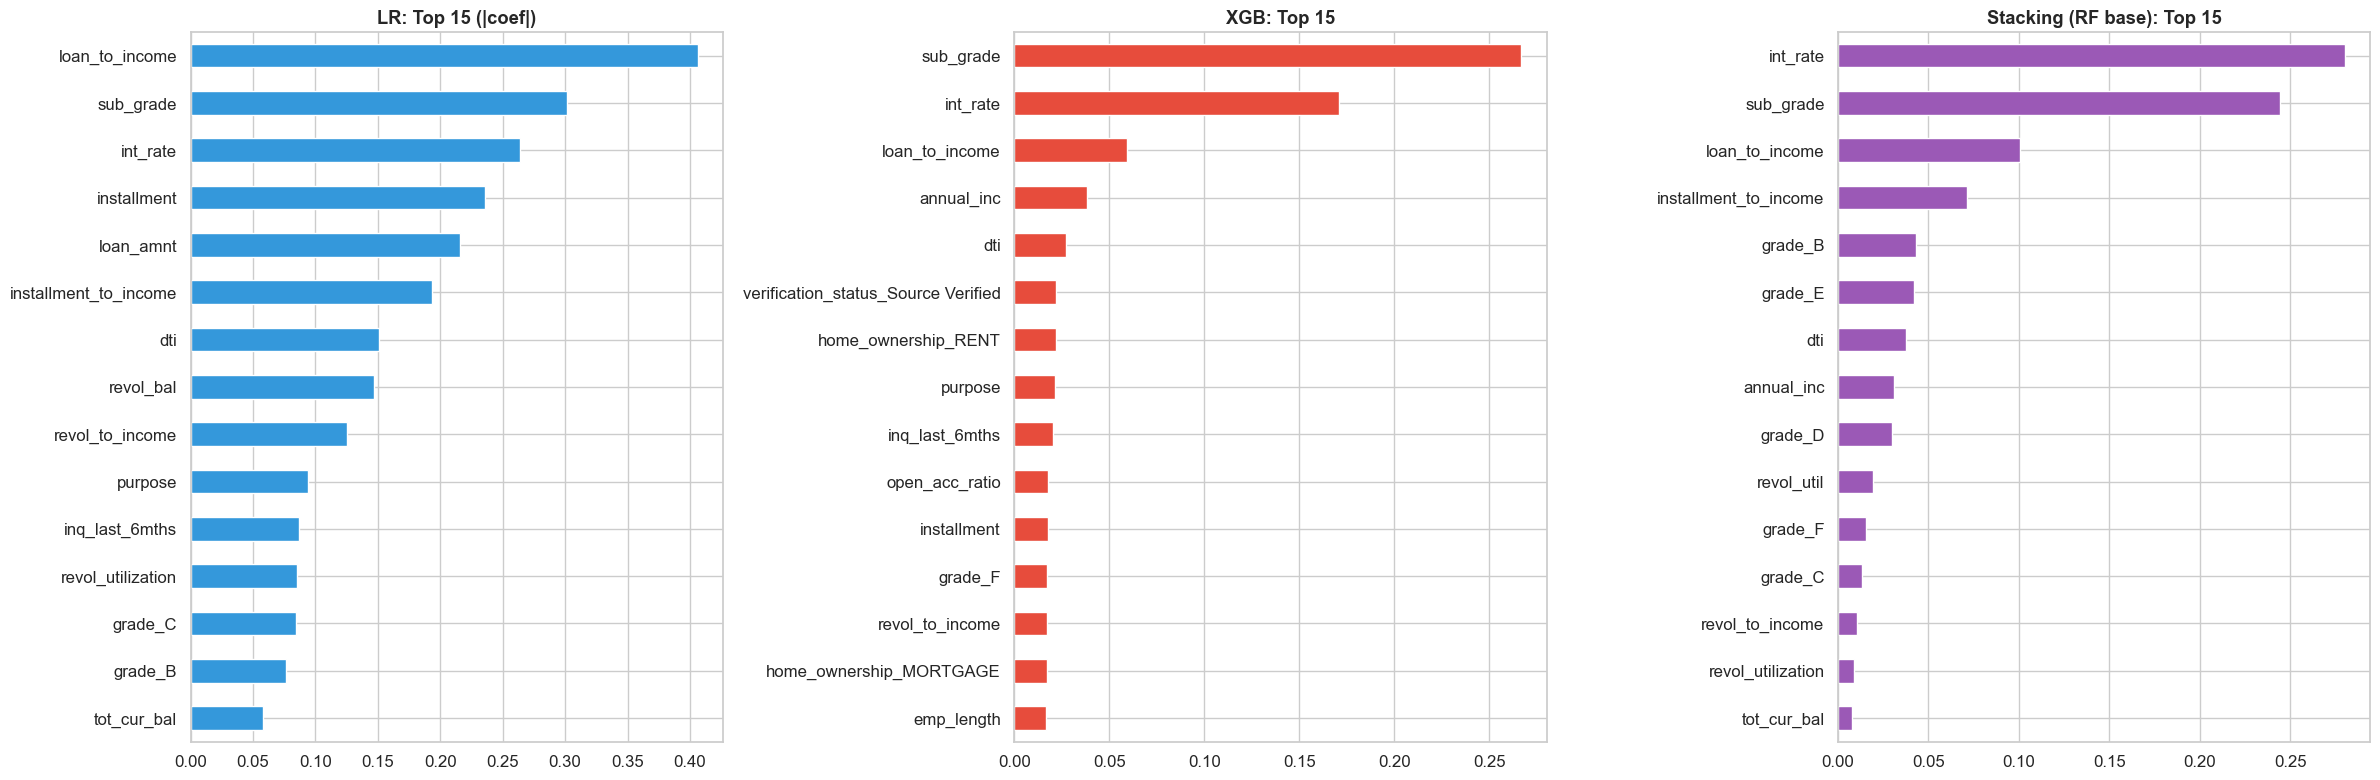

In [28]:
fig, axes = plt.subplots(1,3,figsize=(24,8))
pd.Series(np.abs(lr_best.coef_[0]), index=feature_names).nlargest(15).sort_values().plot(
    kind="barh", ax=axes[0], color="#3498db")
axes[0].set_title("LR: Top 15 (|coef|)", fontweight="bold")
pd.Series(xgb_best.feature_importances_, index=feature_names).nlargest(15).sort_values().plot(
    kind="barh", ax=axes[1], color="#e74c3c")
axes[1].set_title("XGB: Top 15", fontweight="bold")
# Stacking: use RF base learner's feature importance
rf_model = stack.named_estimators_["rf"]
pd.Series(rf_model.feature_importances_, index=feature_names).nlargest(15).sort_values().plot(
    kind="barh", ax=axes[2], color="#9b59b6")
axes[2].set_title("Stacking (RF base): Top 15", fontweight="bold")
plt.tight_layout(); plt.show()


### 5.6 Final Comparison & Recommendation


In [29]:
summary = pd.DataFrame({"Logistic Regression": lr_m, "XGBoost": xgb_m, "Stacking Ensemble": stack_m}).T
print("="*70)
print("FINAL MODEL COMPARISON (3 Models)")
print("="*70)
print(summary.to_string())
best = summary["F1"].idxmax()
print(f"\nBest Model: {best}")
print(f"  ROC-AUC : {summary.loc[best,'ROC-AUC']:.4f}")
print(f"  F1-Score: {summary.loc[best,'F1']:.4f}")
print(f"  Recall  : {summary.loc[best,'Recall']:.4f}")
print(f"\nBusiness Recommendation:")
print(f"  1. Deploy {best} with optimized threshold")
print(f"  2. Focus monitoring on False Negatives (approved bad loans)")
print(f"  3. Retrain quarterly with fresh data")


FINAL MODEL COMPARISON (3 Models)
                     Accuracy  Precision    Recall        F1   ROC-AUC  Train_F1
Logistic Regression  0.663210   0.309460  0.628030  0.414618  0.704292  0.415515
XGBoost              0.685924   0.324534  0.604595  0.422356  0.713809  0.450194
Stacking Ensemble    0.676628   0.319538  0.622143  0.422220  0.713769  0.445873

Best Model: XGBoost
  ROC-AUC : 0.7138
  F1-Score: 0.4224
  Recall  : 0.6046

Business Recommendation:
  1. Deploy XGBoost with optimized threshold
  2. Focus monitoring on False Negatives (approved bad loans)
  3. Retrain quarterly with fresh data
